<a href="https://colab.research.google.com/github/sanaabed41/smartnetenergy/blob/rima_jr/ML_PFA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importation  des bibliothèques**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Imports OK")

Imports OK


# **Chargement des données**

In [ ]:
BSinfo= pd.read_csv("/content/drive/MyDrive/Colab Notebooks/PFA/BSinfo.csv")
CLdata= pd.read_csv("/content/drive/MyDrive/Colab Notebooks/PFA/CLdata.csv")
ECdata= pd.read_csv("/content/drive/MyDrive/Colab Notebooks/PFA/ECdata.csv")

# **Exploration des données (EDA)**

In [ ]:
print(f"BSinfo  : {BSinfo.shape}  — {BSinfo.shape[0]} antennes")
print(f"CLdata  : {CLdata.shape}  — {CLdata.shape[0]} mesures de charge")
print(f"ECdata  : {ECdata.shape}  — {ECdata.shape[0]} mesures d'énergie")


BSinfo  : (1217, 8)  — 1217 antennes
CLdata  : (125575, 10)  — 125575 mesures de charge
ECdata  : (92629, 3)  — 92629 mesures d'énergie


In [ ]:
print("=== BSinfo - Caracteristiques des antennes ===")
print(BSinfo.head())
print("\n=== CLdata - Charge reseau par heure ===")
print(CLdata.head())
print("\n=== ECdata - Consommation energie (cible) ===")
print(ECdata.head())

=== BSinfo - Caracteristiques des antennes ===
    BS CellName RUType   Mode  Frequency  Bandwidth  Antennas   TXpower
0  B_0    Cell0  Type1  Mode2      365.0         20         4  6.875934
1  B_1    Cell0  Type2  Mode2      532.0         20         4  6.875934
2  B_2    Cell0  Type1  Mode2      365.0         20         4  6.875934
3  B_3    Cell0  Type2  Mode2      532.0         20         4  6.875934
4  B_4    Cell0  Type2  Mode2      532.0         20         4  6.875934

=== CLdata - Charge reseau par heure ===
            Time   BS CellName      load  ESMode1  ESMode2  ESMode3  ESMode4  \
0  1/1/2023 1:00  B_0    Cell0  0.487936      0.0      0.0      0.0        0   
1  1/1/2023 2:00  B_0    Cell0  0.344468      0.0      0.0      0.0        0   
2  1/1/2023 3:00  B_0    Cell0  0.193766      0.0      0.0      0.0        0   
3  1/1/2023 4:00  B_0    Cell0  0.222383      0.0      0.0      0.0        0   
4  1/1/2023 5:00  B_0    Cell0  0.175436      0.0      0.0      0.0        0   

In [ ]:
# Uniformiser le format Time des le debut
CLdata['Time'] = pd.to_datetime(CLdata['Time']).dt.strftime('%Y-%m-%d %H:%M:%S')
ECdata['Time'] = pd.to_datetime(ECdata['Time']).dt.strftime('%Y-%m-%d %H:%M:%S')


In [ ]:


# --- BSinfo ---
print("=== BSinfo ===")
print("Types de colonnes :")
print(BSinfo.dtypes)
print("\nValeurs manquantes :")
print(BSinfo.isnull().sum())

# --- CLdata ---
print("\n=== CLdata ===")
print("Types de colonnes :")
print(CLdata.dtypes)
print("\nValeurs manquantes :")
print(CLdata.isnull().sum())

# --- ECdata ---
print("\n=== ECdata ===")
print("Types de colonnes :")
print(ECdata.dtypes)
print("\nValeurs manquantes :")
print(ECdata.isnull().sum())

=== BSinfo ===
Types de colonnes :
BS            object
CellName      object
RUType        object
Mode          object
Frequency    float64
Bandwidth      int64
Antennas       int64
TXpower      float64
dtype: object

Valeurs manquantes :
BS           0
CellName     0
RUType       0
Mode         0
Frequency    0
Bandwidth    0
Antennas     0
TXpower      0
dtype: int64

=== CLdata ===
Types de colonnes :
Time         object
BS           object
CellName     object
load        float64
ESMode1     float64
ESMode2     float64
ESMode3     float64
ESMode4       int64
ESMode5     float64
ESMode6     float64
dtype: object

Valeurs manquantes :
Time        0
BS          0
CellName    0
load        0
ESMode1     0
ESMode2     0
ESMode3     0
ESMode4     0
ESMode5     0
ESMode6     0
dtype: int64

=== ECdata ===
Types de colonnes :
Time       object
BS         object
Energy    float64
dtype: object

Valeurs manquantes :
Time      0
BS        0
Energy    0
dtype: int64


BS, CellName, RUType, Mode, Time sont de type object (texte) — le modèle ML ne
peut pas lire du texte directement, il faudra les transformer en chiffres plus tard   

ESMode4 est int64 alors que ESMode1/2/3/5/6 sont float64 — c'est une incohérence mineure, on la corrigera   

Energy est bien float64 — c'est notre cible, en Watts

In [ ]:


# --- BSinfo : colonnes numériques ---
print("=== BSinfo - Statistiques des colonnes numeriques ===")
print(BSinfo[['Frequency', 'Bandwidth', 'Antennas', 'TXpower']].describe())

# --- CLdata : load et ESModes ---
print("\n=== CLdata - Statistiques de load ===")
print(CLdata['load'].describe())

print("\n=== CLdata - Taux d activation de chaque ESMode (%) ===")
es_cols = ['ESMode1','ESMode2','ESMode3','ESMode4','ESMode5','ESMode6']
for col in es_cols:
    taux = CLdata[col].sum() / len(CLdata) * 100
    print(f"  {col} : {taux:.3f}%")

# --- ECdata : Energy ---
print("\n=== ECdata - Statistiques de Energy (notre cible) ===")
print(ECdata['Energy'].describe())

=== BSinfo - Statistiques des colonnes numeriques ===
         Frequency    Bandwidth     Antennas      TXpower
count  1217.000000  1217.000000  1217.000000  1217.000000
mean    408.413334    12.706656     3.908792     6.924197
std     158.536230     7.397005     9.115707     0.464575
min     155.600000     2.000000     1.000000     5.381166
25%     365.000000     8.000000     2.000000     6.576981
50%     426.980000    10.000000     2.000000     6.875934
75%     532.000000    20.000000     2.000000     7.325859
max     979.998000    20.000000    64.000000     8.375336

=== CLdata - Statistiques de load ===
count    125575.000000
mean          0.239009
std           0.235750
min           0.000000
25%           0.055080
50%           0.153410
75%           0.352220
max           0.993957
Name: load, dtype: float64

=== CLdata - Taux d activation de chaque ESMode (%) ===
  ESMode1 : 4.013%
  ESMode2 : 3.672%
  ESMode3 : 0.008%
  ESMode4 : 0.000%
  ESMode5 : 0.001%
  ESMode6 : 3.877%

==


## **BSinfo — Caractéristiques fixes des antennes**

*   **Frequency (fréquence porteuse)**

Valeurs entre **155 et 980,** moyenne 408   
=> Plus la **fréquence est élevée**, plus les circuits électroniques de l'antenne travaillent fort → **plus elle consomme d'énergie**      
Il y a une vraie diversité de fréquences entre les antennes → cette colonne aidera le modèle à distinguer les antennes qui consomment naturellement plus.  
=> feature importante, le modèle va apprendre que les antennes haute fréquence ont un plancher de consommation plus élevé              



*   **Bandwidth (bande passante)**

Entre 2 et 20 MHz, moyenne 12.7     
**Plus la bande est large**, plus le **processeur numérique** de l'antenne **traite de données**→ **plus elle consomme**    
=> feature utile, elle complète Frequency pour expliquer la consommation de base

*   **Antennas (nombre d'antennes MIMO)**

Médiane = 2, max = 64 — grande disparité  
Chaque antenne active consomme de l'énergie supplémentaire. **Une antenne avec 64 éléments consomme beaucoup plus qu'une avec 2 éléments à puissance identique**     
=>c'est une des features les plus importantes. Elle **explique directement pourquoi deux antennes avec la même charge consomment très différemment**      
*   **TXpower (puissance de transmission)**

Entre 5.38 et 8.37, peu de variabilité (écart-type 0.46)    

C'est **la puissance radio émise vers les téléphones**. **Plus elle est élevée, plus la consommation est élevée**   
    

*   **RUType (type de matériel)**

12 types différents — chaque type correspond à un modèle d'antenne différent  
Chaque fabricant a une courbe de consommation différente : **à puissance et charge identiques, un Type1 et un Type6 ne consomment pas pareil**

=>c'est probablement la feature la plus importante de BSinfo. Le modèle va apprendre une "empreinte énergétique" pour chaque type.    





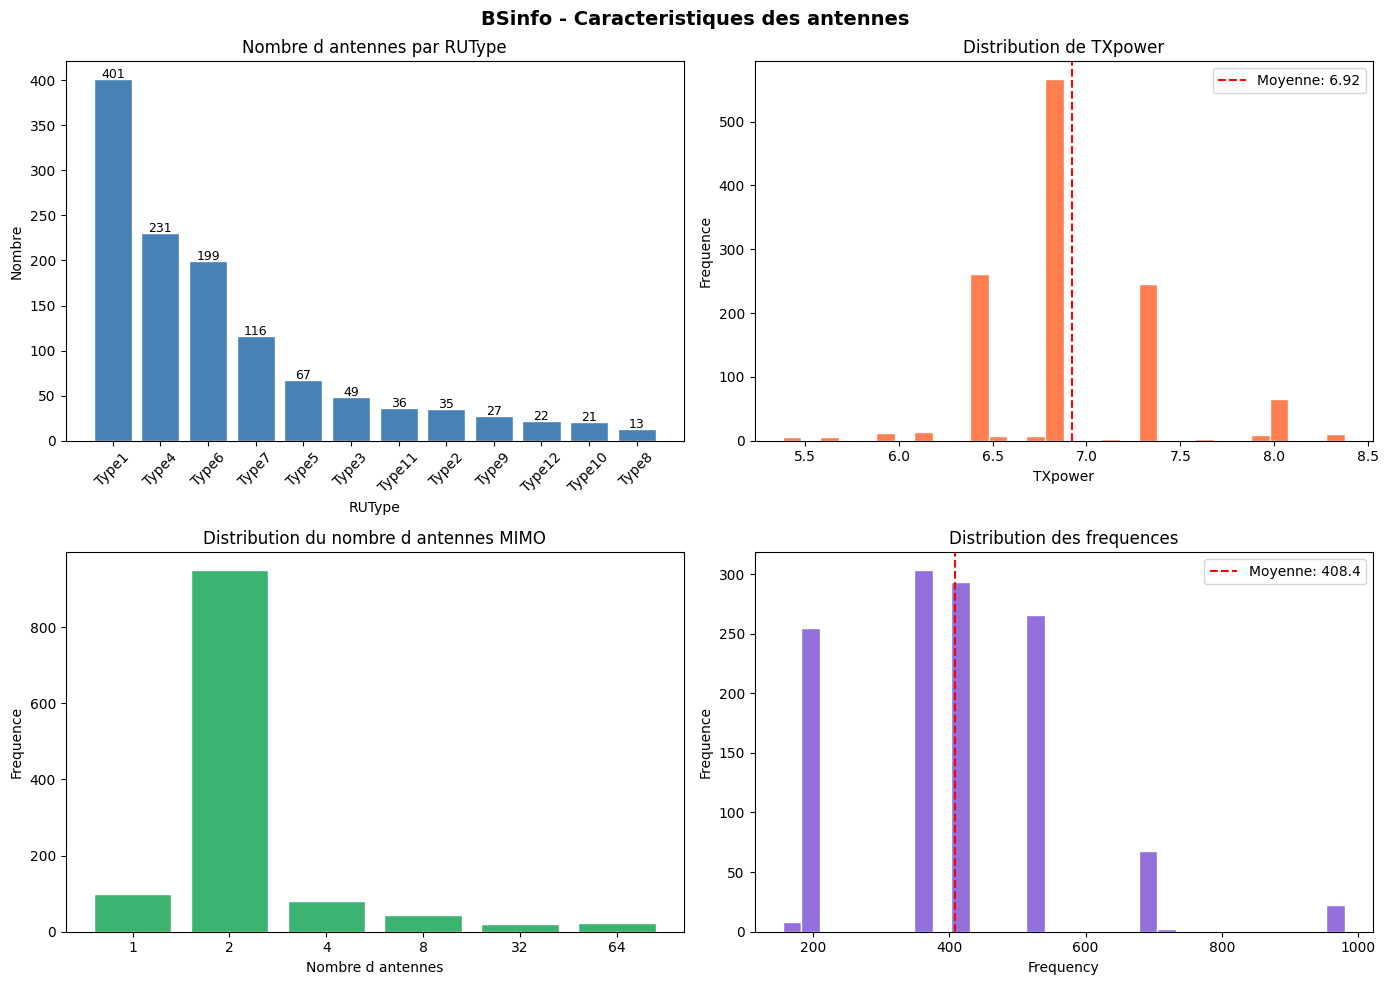

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('BSinfo - Caracteristiques des antennes', fontsize=14, fontweight='bold')

rc = BSinfo['RUType'].value_counts()
axes[0,0].bar(rc.index, rc.values, color='steelblue', edgecolor='white')
axes[0,0].set_title('Nombre d antennes par RUType')
axes[0,0].set_xlabel('RUType')
axes[0,0].set_ylabel('Nombre')
axes[0,0].tick_params(axis='x', rotation=45)
for i, v in enumerate(rc.values):
    axes[0,0].text(i, v+1, str(v), ha='center', fontsize=9)

axes[0,1].hist(BSinfo['TXpower'], bins=30, color='coral', edgecolor='white')
axes[0,1].axvline(BSinfo['TXpower'].mean(), color='red', linestyle='--',
                   label=f"Moyenne: {BSinfo['TXpower'].mean():.2f}")
axes[0,1].set_title('Distribution de TXpower')
axes[0,1].set_xlabel('TXpower')
axes[0,1].set_ylabel('Frequence')
axes[0,1].legend()

ac = BSinfo['Antennas'].value_counts().sort_index()
axes[1,0].bar(ac.index.astype(str), ac.values, color='mediumseagreen', edgecolor='white')
axes[1,0].set_title('Distribution du nombre d antennes MIMO')
axes[1,0].set_xlabel('Nombre d antennes')
axes[1,0].set_ylabel('Frequence')

axes[1,1].hist(BSinfo['Frequency'], bins=30, color='mediumpurple', edgecolor='white')
axes[1,1].axvline(BSinfo['Frequency'].mean(), color='red', linestyle='--',
                   label=f"Moyenne: {BSinfo['Frequency'].mean():.1f}")
axes[1,1].set_title('Distribution des frequences')
axes[1,1].set_xlabel('Frequency')
axes[1,1].set_ylabel('Frequence')
axes[1,1].legend()

plt.tight_layout()
plt.show()

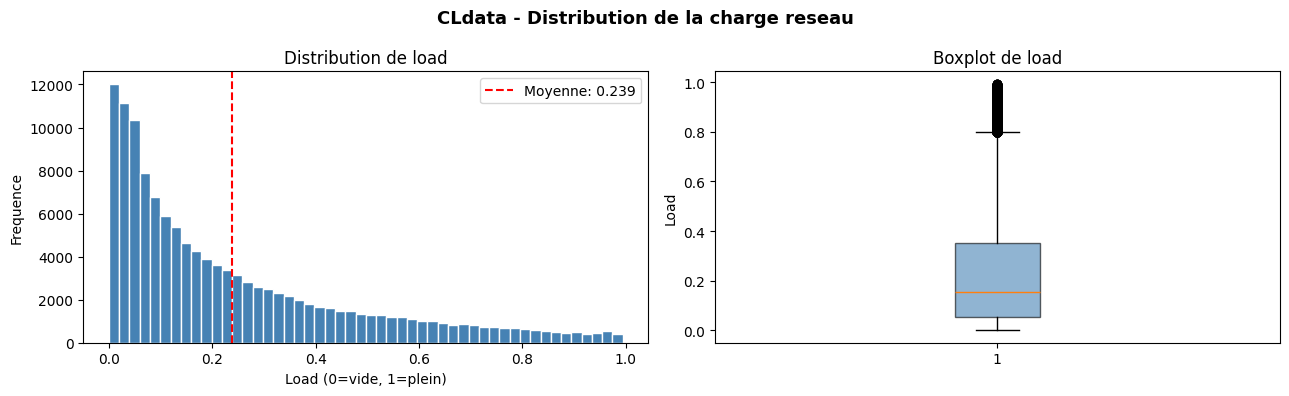

Load min    : 0.0000
Load max    : 0.9940
Load moyen  : 0.2390
% load = 0  : 0.1%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('CLdata - Distribution de la charge reseau', fontsize=13, fontweight='bold')

axes[0].hist(CLdata['load'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(CLdata['load'].mean(), color='red', linestyle='--',
                label=f"Moyenne: {CLdata['load'].mean():.3f}")
axes[0].set_title('Distribution de load')
axes[0].set_xlabel('Load (0=vide, 1=plein)')
axes[0].set_ylabel('Frequence')
axes[0].legend()

axes[1].boxplot(CLdata['load'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot de load')
axes[1].set_ylabel('Load')

plt.tight_layout()
plt.show()

print(f'Load min    : {CLdata["load"].min():.4f}')
print(f'Load max    : {CLdata["load"].max():.4f}')
print(f'Load moyen  : {CLdata["load"].mean():.4f}')
print(f'% load = 0  : {(CLdata["load"]==0).mean()*100:.1f}%')

Graphique Load — Distribution et Boxplot
La distribution montre que la majorité des mesures ont un load entre 0 et 0.3. Le réseau est peu chargé la plupart du temps. Le boxplot ne montre pas d'outliers anormaux — les valeurs élevées de load sont réelles et correspondent aux heures de pointe.
Importance pour le modèle : load est la feature dynamique numéro 1. C'est elle qui explique pourquoi la même antenne consomme 55W à 3h du matin et 300W à 18h. Sans load, le modèle ne peut pas voir les variations temporelles de consommation.

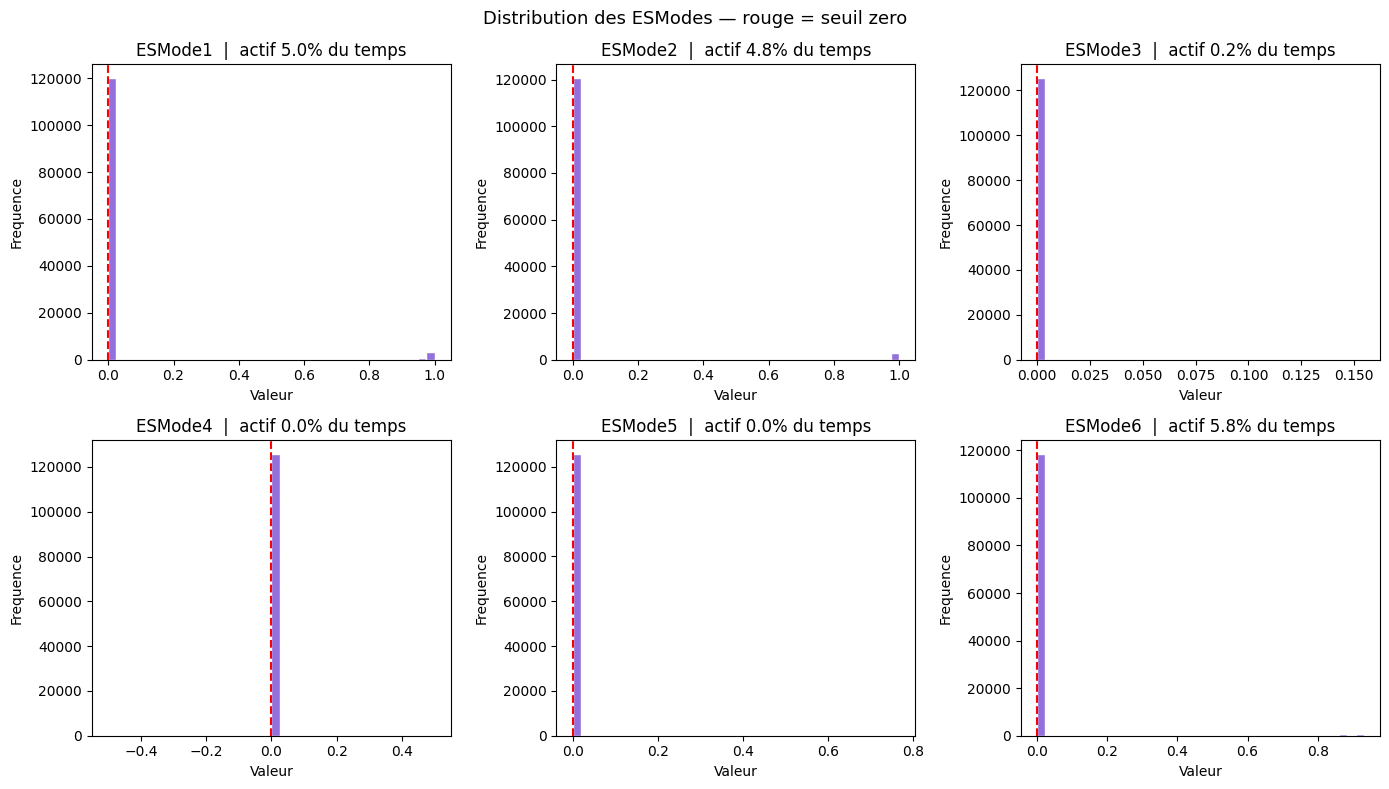

Bilan ESModes :
  ESMode1 : 4.970%  ->  GARDER
  ESMode2 : 4.820%  ->  GARDER
  ESMode3 : 0.177%  ->  GARDER
  ESMode4 : 0.000%  ->  SUPPRIMER
  ESMode5 : 0.002%  ->  SUPPRIMER
  ESMode6 : 5.837%  ->  GARDER


In [ ]:
es_cols = ['ESMode1','ESMode2','ESMode3','ESMode4','ESMode5','ESMode6']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(es_cols):
    taux = (CLdata[col] > 0).mean() * 100
    axes[i].hist(CLdata[col], bins=40, color='mediumpurple', edgecolor='white')
    axes[i].axvline(0, color='red', linewidth=1.5, linestyle='--')
    axes[i].set_title(f'{col}  |  actif {taux:.1f}% du temps')
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Frequence')

plt.suptitle('Distribution des ESModes — rouge = seuil zero', fontsize=13)
plt.tight_layout()
plt.show()

print('Bilan ESModes :')
for col in es_cols:
    taux = (CLdata[col] > 0).mean() * 100
    decision = 'GARDER' if taux > 0.1 else 'SUPPRIMER'
    print(f'  {col} : {taux:.3f}%  ->  {decision}')

Graphique ESModes
ESMode1, ESMode2, ESMode6 sont actifs environ 5% du temps chacun. On voit deux pics clairs sur chaque graphique — un grand pic à 0 (inactif) et un petit pic à 1 (actif). Ces modes réduisent la consommation quand ils sont activés.
ESMode3, ESMode4, ESMode5 sont quasi ou totalement inactifs. Leurs graphiques ne montrent qu'un seul pic à 0 — aucune variation.
Importance pour le modèle :

ESMode1/2/6 : quand actifs ils indiquent que l'opérateur a réduit la puissance → Energy baisse. Le modèle doit apprendre cette relation. Si on les supprime, le modèle ne comprendra pas pourquoi certaines mesures ont une consommation anormalement basse malgré une charge normale
ESMode3/4/5 : une colonne constante ou quasi-constante ne peut rien apprendre au modèle. Elle ajoute juste du bruit inutile → on les supprime

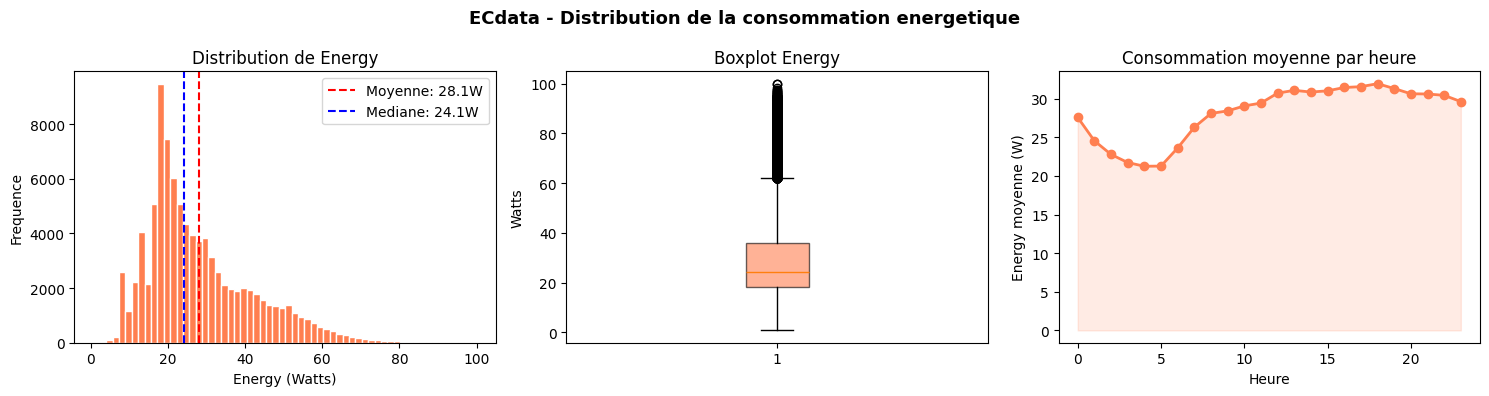

Energy min    : 0.75 W
Energy max    : 100.00 W
Energy moyenne: 28.14 W
Energy mediane: 24.07 W


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('ECdata - Distribution de la consommation energetique', fontsize=13, fontweight='bold')

axes[0].hist(ECdata['Energy'], bins=60, color='coral', edgecolor='white')
axes[0].axvline(ECdata['Energy'].mean(), color='red', linestyle='--',
                label=f"Moyenne: {ECdata['Energy'].mean():.1f}W")
axes[0].axvline(ECdata['Energy'].median(), color='blue', linestyle='--',
                label=f"Mediane: {ECdata['Energy'].median():.1f}W")
axes[0].set_title('Distribution de Energy')
axes[0].set_xlabel('Energy (Watts)')
axes[0].set_ylabel('Frequence')
axes[0].legend()

axes[1].boxplot(ECdata['Energy'], patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.6))
axes[1].set_title('Boxplot Energy')
axes[1].set_ylabel('Watts')
# Profil horaire sans modifier ECdata
hour_tmp = pd.to_datetime(ECdata['Time']).dt.hour
e_heure  = ECdata.groupby(hour_tmp)['Energy'].mean()
axes[2].plot(e_heure.index, e_heure.values, marker='o', color='coral', linewidth=2)
axes[2].fill_between(e_heure.index, e_heure.values, alpha=0.15, color='coral')
axes[2].set_title('Consommation moyenne par heure')
axes[2].set_xlabel('Heure')
axes[2].set_ylabel('Energy moyenne (W)')
plt.tight_layout()
plt.show()
print(f'Energy min    : {ECdata["Energy"].min():.2f} W')
print(f'Energy max    : {ECdata["Energy"].max():.2f} W')
print(f'Energy moyenne: {ECdata["Energy"].mean():.2f} W')
print(f'Energy mediane: {ECdata["Energy"].median():.2f} W')

Graphique Energy — Distribution, Boxplot, Profil horaire
La distribution est asymétrique à droite avec un pic autour de 15–20W et une longue queue jusqu'à 100W. La moyenne (28W) dépasse la médiane (24W) ce qui confirme l'asymétrie.
Le boxplot montre des outliers au-dessus de 65W. Ces valeurs sont physiquement réelles — elles correspondent aux heures où le réseau est saturé. Les supprimer serait une erreur car le modèle doit savoir prédire ces situations de forte charge.
Le profil horaire est la découverte la plus importante : consommation basse de 0h à 6h (15–18W) puis montée progressive jusqu'au pic de 18h–20h (30–32W). Ce pattern est très régulier et prévisible.
Importance pour le modèle :

Ce pattern horaire régulier signifie que la feature hour qu'on va créer sera très prédictive
La distribution asymétrique signifie que le modèle doit traiter les petites valeurs (nuit) et les grandes valeurs (pointe) différemment
Les outliers conservés permettront au modèle d'apprendre le comportement en charge maximale

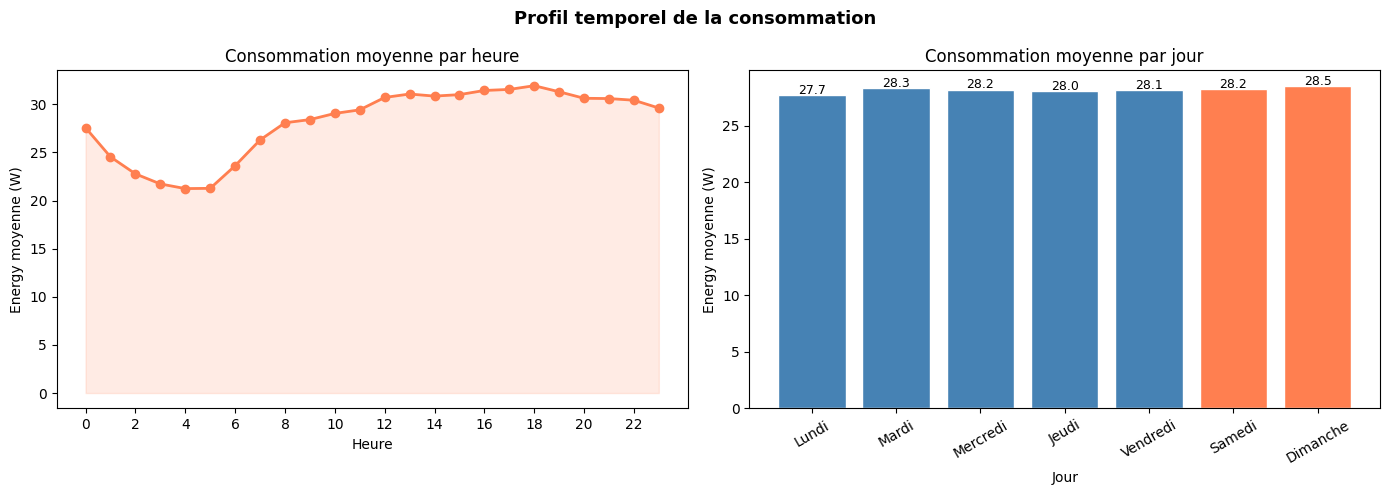

In [ ]:
hour_tmp = pd.to_datetime(ECdata['Time']).dt.hour
jour_tmp = pd.to_datetime(ECdata['Time']).dt.dayofweek

e_heure = ECdata.groupby(hour_tmp)['Energy'].mean()
e_jour  = ECdata.groupby(jour_tmp)['Energy'].mean()
jours   = ['Lundi','Mardi','Mercredi','Jeudi','Vendredi','Samedi','Dimanche']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Profil temporel de la consommation', fontsize=13, fontweight='bold')

axes[0].plot(e_heure.index, e_heure.values, marker='o', color='coral', linewidth=2)
axes[0].fill_between(e_heure.index, e_heure.values, alpha=0.15, color='coral')
axes[0].set_title('Consommation moyenne par heure')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('Energy moyenne (W)')
axes[0].set_xticks(range(0, 24, 2))

couleurs = ['steelblue']*5 + ['coral']*2
axes[1].bar(jours, e_jour.values, color=couleurs, edgecolor='white')
axes[1].set_title('Consommation moyenne par jour')
axes[1].set_xlabel('Jour')
axes[1].set_ylabel('Energy moyenne (W)')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(e_jour.values):
    axes[1].text(i, v+0.1, f'{v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Par heure :
La consommation commence à 28W à minuit, descend jusqu'à son minimum à 5h du matin (21W) — c'est l'heure où le réseau est le plus vide. Ensuite elle remonte progressivement jusqu'à son maximum entre 18h et 20h (32W) — c'est l'heure de pointe du soir. Ce pattern est très régulier et prévisible.
Importance pour le modèle : cette courbe confirme qu'on doit créer une feature hour — l'heure de la journée est clairement liée à la consommation. On créera aussi is_night pour marquer les heures 0h–6h où la consommation est minimale.
Par jour :
Les valeurs sont très proches entre tous les jours — entre 27.7W (lundi) et 28.5W (dimanche). La différence semaine/week-end est minime (moins de 1W). Contrairement à ce qu'on attendait, le comportement ne change pas significativement entre semaine et week-end.
Importance pour le modèle : la feature is_weekend aura peu d'impact ici. Le jour de la semaine n'est pas un facteur déterminant dans ce dataset. On la crée quand même mais elle sera probablement peu utilisée par le modèle.

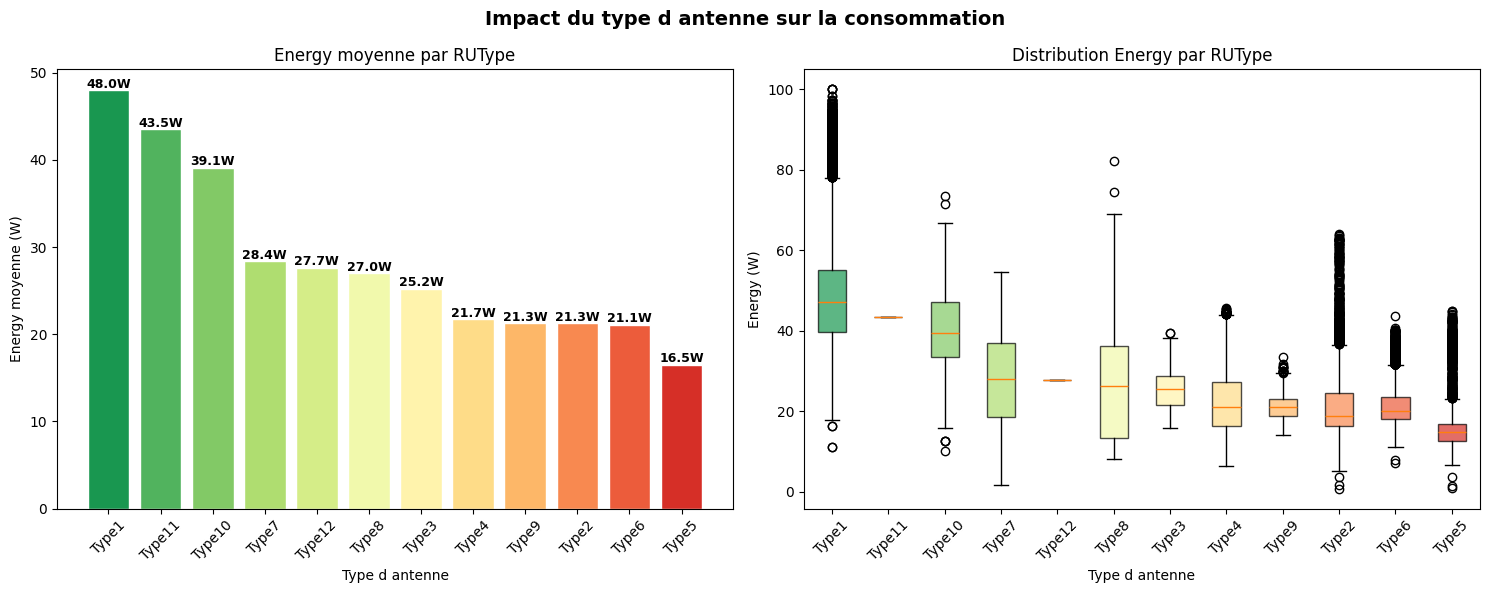

In [ ]:
df_ru = ECdata.merge(BSinfo[['BS','RUType']], on='BS', how='left')
e_ru  = df_ru.groupby('RUType')['Energy'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Impact du type d antenne sur la consommation', fontsize=14, fontweight='bold')

couleurs = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(e_ru)))
bars = axes[0].bar(e_ru.index, e_ru.values, color=couleurs, edgecolor='white')
axes[0].set_title('Energy moyenne par RUType')
axes[0].set_xlabel('Type d antenne')
axes[0].set_ylabel('Energy moyenne (W)')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, e_ru.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                  f'{val:.1f}W', ha='center', fontsize=9, fontweight='bold')

data_bp = [df_ru[df_ru['RUType']==ru]['Energy'].values for ru in e_ru.index]
bp = axes[1].boxplot(data_bp, patch_artist=True, labels=e_ru.index)
for patch, c in zip(bp['boxes'], couleurs):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[1].set_title('Distribution Energy par RUType')
axes[1].set_xlabel('Type d antenne')
axes[1].set_ylabel('Energy (W)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Barplot — Energy moyenne par RUType :
Il y a une différence énorme entre les types d'antennes. Type1 consomme en moyenne 48W, soit presque 3 fois plus que Type5 qui consomme seulement 16.5W. Cela confirme que le modèle matériel de l'antenne est un facteur déterminant de la consommation.
On peut regrouper les types en 3 catégories :

Forte consommation : Type1 (48W), Type11 (43.5W), Type10 (39.1W)
Consommation moyenne : Type7 (28.4W), Type12 (27.7W), Type8 (27W)
Faible consommation : Type3 à Type5 (16.5W à 25.2W)

Boxplot — Distribution par RUType :
Type1 a la boîte la plus large et les outliers les plus élevés (jusqu'à 100W). Cela signifie que Type1 a une grande variabilité de consommation — elle peut consommer peu la nuit et beaucoup en heure de pointe. Type12 a une boîte très étroite — sa consommation est stable et prévisible. Type5 a la boîte la plus basse et la plus compacte — c'est l'antenne la plus économe et la plus stable.
Importance pour le modèle : RUType est probablement la feature la plus importante du projet. Deux antennes identiques en charge et en configuration mais de types différents peuvent consommer 3 fois plus ou moins. Le modèle doit absolument apprendre une empreinte énergétique différente pour chaque type.
Décision : encoder RUType en chiffres — c'est obligatoire car le modèle ne lit pas le texte.

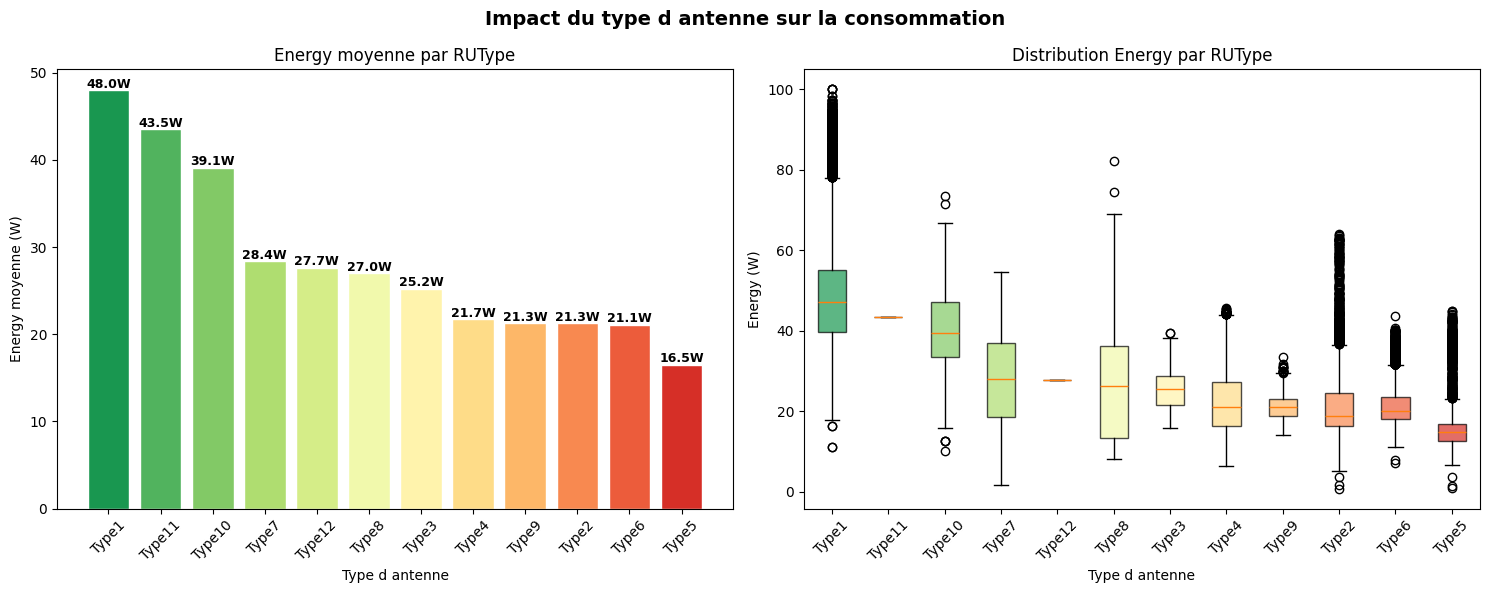

In [ ]:
df_ru = ECdata.merge(BSinfo[['BS','RUType']], on='BS', how='left')
e_ru  = df_ru.groupby('RUType')['Energy'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Impact du type d antenne sur la consommation', fontsize=14, fontweight='bold')

couleurs = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(e_ru)))
bars = axes[0].bar(e_ru.index, e_ru.values, color=couleurs, edgecolor='white')
axes[0].set_title('Energy moyenne par RUType')
axes[0].set_xlabel('Type d antenne')
axes[0].set_ylabel('Energy moyenne (W)')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, e_ru.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                  f'{val:.1f}W', ha='center', fontsize=9, fontweight='bold')

data_bp = [df_ru[df_ru['RUType']==ru]['Energy'].values for ru in e_ru.index]
bp = axes[1].boxplot(data_bp, patch_artist=True, labels=e_ru.index)
for patch, c in zip(bp['boxes'], couleurs):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[1].set_title('Distribution Energy par RUType')
axes[1].set_xlabel('Type d antenne')
axes[1].set_ylabel('Energy (W)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Scatter plot Load vs Energy :
La relation entre load et Energy est positive — quand la charge augmente, la consommation augmente. Mais ce n'est pas une ligne droite parfaite. On voit un nuage de points large, surtout pour les faibles valeurs de load (0 à 0.2) où Energy varie entre 5W et 60W malgré une charge similaire.
Cela confirme ce qu'on a dit depuis le début — load seul ne suffit pas à expliquer la consommation. À load=0.1, certaines antennes consomment 10W et d'autres 50W. Cette différence vient du RUType, du nombre d'antennes et de TXpower.
Barplot Energy par tranche de load :
La progression est très claire et régulière :

Load faible (tranche 0) → 21W en moyenne
Load fort (tranche 9) → 55W en moyenne

La consommation augmente de 21W à 55W soit une augmentation de 2.6x entre load minimum et maximum. Mais même à load=0 l'antenne consomme déjà 21W — c'est la consommation statique de base qu'on ne peut pas éliminer.
Importance pour le modèle : load est une feature très importante mais insuffisante seule. Le modèle aura besoin de combiner load avec RUType et Antennas pour faire de bonnes prédictions. C'est pour ça qu'on créera une interaction load × TXpower et load × Antennas dans le feature engineering.


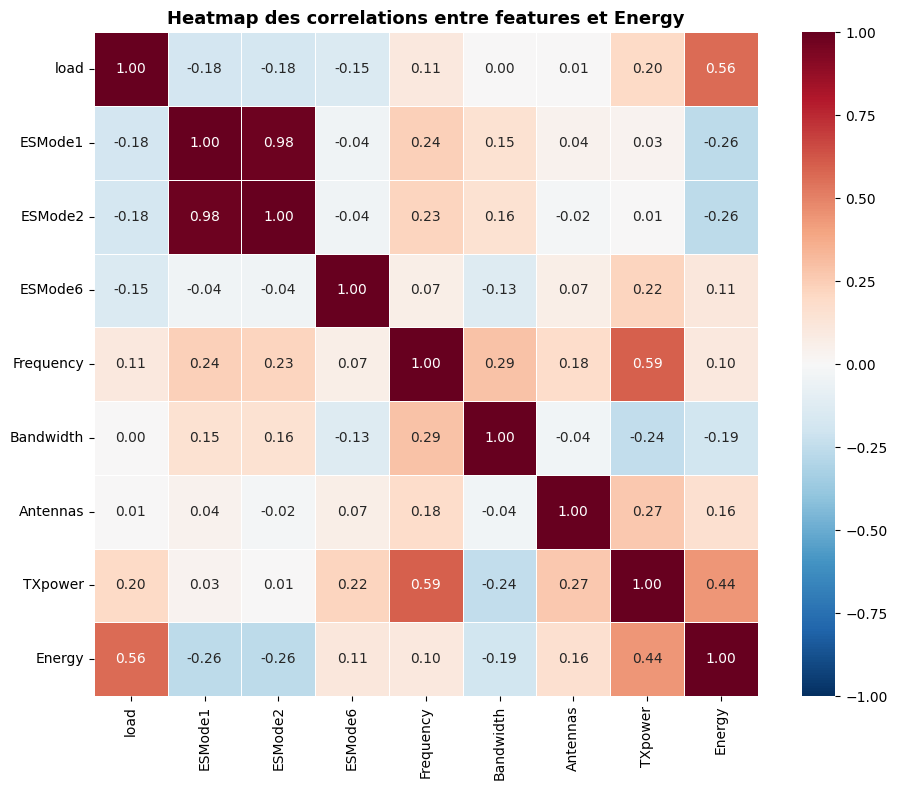

Correlation avec Energy (triee) :
load         0.563
TXpower      0.443
Antennas     0.159
ESMode6      0.112
Frequency    0.104
Bandwidth   -0.192
ESMode2     -0.259
ESMode1     -0.262
Name: Energy, dtype: float64


In [ ]:
df_corr = CLdata[['BS','Time','load','ESMode1','ESMode2','ESMode6']].merge(
          ECdata[['BS','Time','Energy']], on=['BS','Time'], how='inner')
df_corr = df_corr.merge(
          BSinfo[['BS','Frequency','Bandwidth','Antennas','TXpower']], on='BS', how='left')

cols = ['load','ESMode1','ESMode2','ESMode6','Frequency','Bandwidth','Antennas','TXpower','Energy']
corr = df_corr[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
             vmin=-1, vmax=1, center=0, square=True, linewidths=0.5)
plt.title('Heatmap des correlations entre features et Energy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation avec Energy (triee) :')
print(corr['Energy'].drop('Energy').sort_values(ascending=False).round(3))

Corrélations avec Energy — du plus important au moins important :
load = 0.56 — corrélation positive forte. C'est la feature la plus corrélée avec Energy. Quand la charge augmente, la consommation augmente. Confirmé par le scatter plot précédent.
TXpower = 0.44 — corrélation positive modérée. Plus la puissance de transmission est élevée, plus l'antenne consomme. Deuxième feature la plus importante.
Antennas = 0.16 — corrélation positive faible. Plus il y a d'antennes MIMO, plus la consommation augmente. La corrélation semble faible ici mais c'est parce que la majorité des antennes ont 2 éléments — les antennes à 32 ou 64 éléments sont rares mais consomment beaucoup plus.
ESMode6 = 0.11 et Frequency = 0.10 — corrélation positive très faible.
Bandwidth = -0.19 — corrélation négative faible. Surprenant — on attendait une corrélation positive. Cela peut signifier que les antennes à large bande sont souvent des antennes récentes plus efficaces énergétiquement.
ESMode1 = -0.26 et ESMode2 = -0.26 — corrélation négative. C'est logique et confirme notre hypothèse — quand ces modes économie sont actifs, la consommation baisse. Le modèle va bien apprendre cet effet de réduction.
Corrélations entre features :
ESMode1 et ESMode2 ont une corrélation de 0.98 entre eux — ils sont quasi identiques. Ils s'activent presque toujours ensemble. On pourrait les fusionner en une seule feature mais on les garde séparés pour l'instant.
Frequency et TXpower ont une corrélation de 0.59 — les antennes haute fréquence ont tendance à avoir une puissance TX plus élevée. C'est cohérent physiquement.         

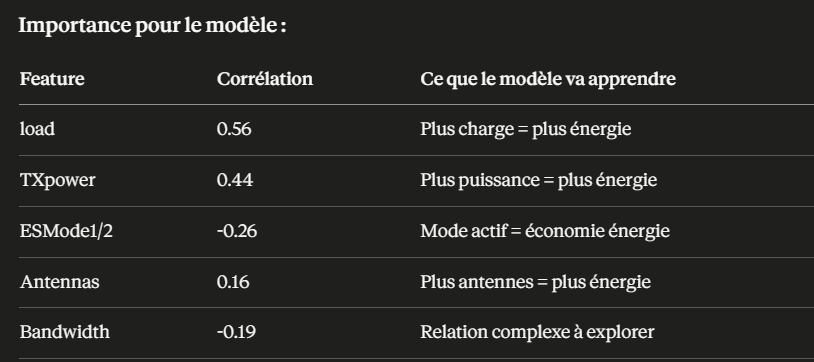            
**=>Décision importante : ces corrélations linéaires sont faibles à modérées. Cela signifie que les relations entre features et Energy ne sont pas simples et linéaires. C'est pour ça qu'on utilisera XGBoost — un modèle capable de capturer des relations complexes et non linéaires que la corrélation de Pearson ne montre pas.**



In [ ]:
df_all = CLdata.merge(ECdata[['BS','Time','Energy']], on=['BS','Time'], how='left')
train  = df_all[df_all['Energy'].notna()].copy()
test   = df_all[df_all['Energy'].isna()].copy()
print(f'Train : {train.shape}  |  Test : {test.shape}')

Train : (98084, 11)  |  Test : (27491, 11)


In [ ]:
# Etape 14 : Nettoyer BSinfo
BSinfo_clean = BSinfo.drop_duplicates(subset='BS', keep='first').copy()
print(f'BSinfo_clean : {BSinfo_clean.shape[0]} lignes')


BSinfo_clean : 1020 lignes


In [ ]:
train = train.merge(BSinfo_clean, on='BS', how='left')
test  = test.merge(BSinfo_clean,  on='BS', how='left')
print(f'Apres merge — Train : {train.shape}  |  Test : {test.shape}')

Apres merge — Train : (98084, 18)  |  Test : (27491, 18)


In [ ]:
train = train.drop(columns=['CellName_y','ESMode3','ESMode4','ESMode5'])
test  = test.drop(columns=['CellName_y','ESMode3','ESMode4','ESMode5'])
train = train.rename(columns={'CellName_x':'CellName'})
test  = test.rename(columns={'CellName_x':'CellName'})
print(f'Colonnes : {list(train.columns)}')

Colonnes : ['Time', 'BS', 'CellName', 'load', 'ESMode1', 'ESMode2', 'ESMode6', 'Energy', 'RUType', 'Mode', 'Frequency', 'Bandwidth', 'Antennas', 'TXpower']


In [ ]:
# Verification coherence physique
zero_load  = train[train['load'] == 0]
low_energy = train[train['Energy'] < 1]
neg_energy = train[train['Energy'] <= 0]
print(f'Lignes load=0      : {len(zero_load)}')
print(f'  Energy moy load=0 : {zero_load["Energy"].mean():.2f} W  -> consommation statique normale')
print(f'Lignes Energy < 1W : {len(low_energy)}')
print(f'Lignes Energy <= 0 : {len(neg_energy)}')
if len(neg_energy) > 0:
    train = train[train['Energy'] > 0].copy()
    print('  => Lignes supprimees')
else:
    print('  => Toutes valeurs positives, coherent')

Lignes load=0      : 29
  Energy moy load=0 : 8.27 W  -> consommation statique normale
Lignes Energy < 1W : 2
Lignes Energy <= 0 : 0
  => Toutes valeurs positives, coherent


In [ ]:
# Etape 17 : Feature Engineering
for df in [train, test]:
    dt = pd.to_datetime(df['Time'])
    df['hour']             = dt.dt.hour
    df['day_of_week']      = dt.dt.dayofweek
    df['month']            = dt.dt.month
    df['is_night']         = (dt.dt.hour <= 6).astype(int)
    df['is_weekend']       = (dt.dt.dayofweek >= 5).astype(int)
    df['load_x_TX']        = df['load'] * df['TXpower']
    df['load_x_ant']       = df['load'] * df['Antennas']
    df['total_ES']         = df['ESMode1'] + df['ESMode2'] + df['ESMode6']
    df['puissance_totale'] = df['TXpower'] * df['Antennas']
    df['load_carre']       = df['load'] ** 2
    df['conso_base']       = df['TXpower'] * df['Antennas'] * df['Bandwidth']
    df['load_par_ant']     = df['load'] / (df['Antennas'] + 1)

# Feature domaine : energie moyenne par RUType
rutype_mean = train.groupby('RUType')['Energy'].mean()
train['rutype_mean_energy'] = train['RUType'].map(rutype_mean)
test['rutype_mean_energy']  = test['RUType'].map(rutype_mean)

print('Features creees OK')
print(f'Train : {train.shape}')

Features creees OK
Train : (98084, 27)


In [ ]:
# Etape 18 : Encodage
from sklearn.preprocessing import LabelEncoder
cols_texte = ['CellName', 'RUType', 'Mode']
encoders   = {}
for col in cols_texte:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]]))
    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])
    encoders[col] = le
    print(f'{col} encode OK')

CellName encode OK
RUType encode OK
Mode encode OK


Borne inferieure : -10.16 W
Borne superieure : 66.37 W
Outliers detectes : 1533 (1.56%)


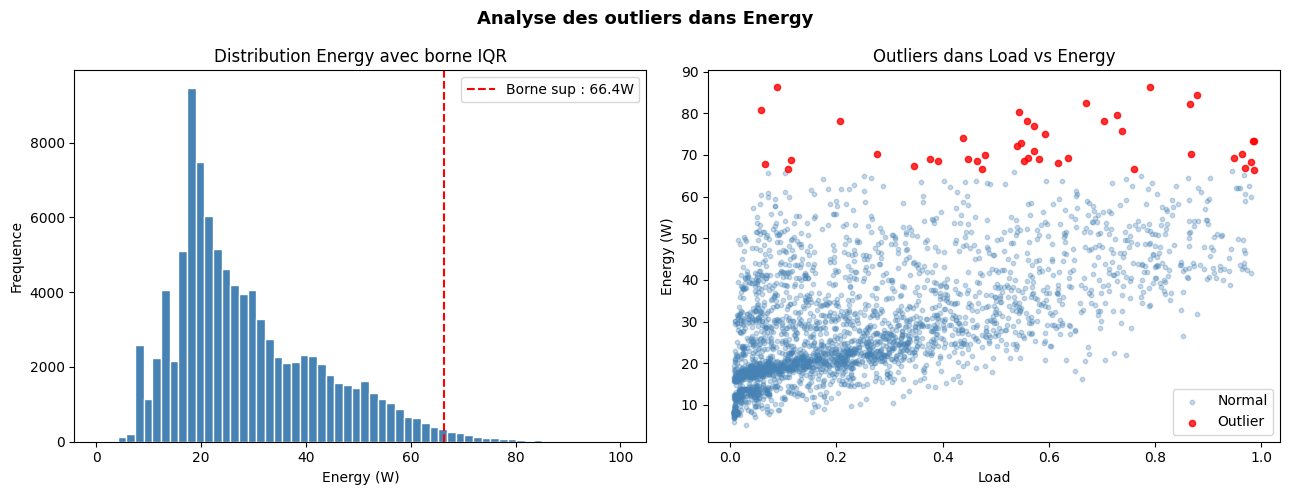

Decision : outliers CONSERVES — heures de forte charge reelles


In [ ]:
# ================================================
# ETAPE 19 : OUTLIERS
# ================================================

Q1  = train['Energy'].quantile(0.25)
Q3  = train['Energy'].quantile(0.75)
IQR = Q3 - Q1
borne_sup = Q3 + 1.5 * IQR
borne_inf = Q1 - 1.5 * IQR

outliers = train[(train['Energy'] < borne_inf) | (train['Energy'] > borne_sup)]

print(f'Borne inferieure : {borne_inf:.2f} W')
print(f'Borne superieure : {borne_sup:.2f} W')
print(f'Outliers detectes : {len(outliers)} ({len(outliers)/len(train)*100:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Analyse des outliers dans Energy', fontsize=13, fontweight='bold')

axes[0].hist(train['Energy'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(borne_sup, color='red', linestyle='--',
                label=f'Borne sup : {borne_sup:.1f}W')
axes[0].set_title('Distribution Energy avec borne IQR')
axes[0].set_xlabel('Energy (W)')
axes[0].set_ylabel('Frequence')
axes[0].legend()

s      = train.sample(3000, random_state=42)
is_out = (s['Energy'] > borne_sup) | (s['Energy'] < borne_inf)
axes[1].scatter(s[~is_out]['load'], s[~is_out]['Energy'],
                alpha=0.3, color='steelblue', s=10, label='Normal')
axes[1].scatter(s[is_out]['load'], s[is_out]['Energy'],
                alpha=0.8, color='red', s=20, label='Outlier')
axes[1].set_title('Outliers dans Load vs Energy')
axes[1].set_xlabel('Load')
axes[1].set_ylabel('Energy (W)')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Decision : outliers CONSERVES — heures de forte charge reelles')

In [ ]:
# ================================================
# ETAPE 20 : PREPARATION X ET Y
# ================================================

train = train.drop(columns=['Time', 'BS'])
test  = test.drop(columns=['Time', 'BS'])

X            = train.drop(columns=['Energy'])
y            = train['Energy']
X_test_final = test.drop(columns=['Energy'])

print(f'X      : {X.shape}')
print(f'y      : {y.shape}')
print(f'X_test : {X_test_final.shape}')
print(f'\nFeatures ({len(X.columns)}) : {list(X.columns)}')

X      : (98084, 24)
y      : (98084,)
X_test : (27491, 24)

Features (24) : ['CellName', 'load', 'ESMode1', 'ESMode2', 'ESMode6', 'RUType', 'Mode', 'Frequency', 'Bandwidth', 'Antennas', 'TXpower', 'hour', 'day_of_week', 'month', 'is_night', 'is_weekend', 'load_x_TX', 'load_x_ant', 'total_ES', 'puissance_totale', 'load_carre', 'conso_base', 'load_par_ant', 'rutype_mean_energy']


In [ ]:
# ================================================
# RETABLIR LE SPLIT CORRECT AVEC 24 FEATURES
# ================================================

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'X_train : {X_train.shape}  — doit avoir 24 features')
print(f'X_val   : {X_val.shape}')

X_train : (78467, 24)  — doit avoir 24 features
X_val   : (19617, 24)


In [ ]:
# ================================================
# ETAPE 22 : FONCTION D EVALUATION
# ================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluer_modele(nom, y_reel, y_predit):
    mae  = mean_absolute_error(y_reel, y_predit)
    rmse = np.sqrt(mean_squared_error(y_reel, y_predit))
    r2   = r2_score(y_reel, y_predit)
    print(f'--- {nom} ---')
    print(f'  MAE  : {mae:.4f} W')
    print(f'  RMSE : {rmse:.4f} W')
    print(f'  R2   : {r2:.4f}')
    print()
    return {'Modele': nom, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

print('Fonction creee OK')

Fonction creee OK


In [ ]:
# ================================================
# REENTRAINER LES MODELES AVEC 24 FEATURES
# ================================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

resultats = []

print('1/4 - Linear Regression...')
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_val)
resultats.append(evaluer_modele('Linear Regression', y_val, y_pred_lr))

print('2/4 - Random Forest...')
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)
resultats.append(evaluer_modele('Random Forest', y_val, y_pred_rf))

print('3/4 - XGBoost...')
xgb = XGBRegressor(n_estimators=500, learning_rate=0.05,
                    max_depth=6, random_state=42, n_jobs=-1, verbosity=0)
xgb.fit(X_train, y_train, verbose=False)
y_pred_xgb = xgb.predict(X_val)
resultats.append(evaluer_modele('XGBoost', y_val, y_pred_xgb))

print('4/4 - LightGBM...')
lgbm = LGBMRegressor(n_estimators=500, learning_rate=0.05,
                      max_depth=6, random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_val)
resultats.append(evaluer_modele('LightGBM', y_val, y_pred_lgbm))

df_resultats = pd.DataFrame(resultats).sort_values('MAE')
print('CLASSEMENT FINAL :')
print(df_resultats.round(4).to_string(index=False))

1/4 - Linear Regression...
--- Linear Regression ---
  MAE  : 3.4639 W
  RMSE : 4.7195 W
  R2   : 0.8914

2/4 - Random Forest...
--- Random Forest ---
  MAE  : 2.8704 W
  RMSE : 4.2381 W
  R2   : 0.9124

3/4 - XGBoost...
--- XGBoost ---
  MAE  : 2.7032 W
  RMSE : 3.9213 W
  R2   : 0.9250

4/4 - LightGBM...
--- LightGBM ---
  MAE  : 2.7104 W
  RMSE : 3.9232 W
  R2   : 0.9250

CLASSEMENT FINAL :
           Modele    MAE   RMSE     R2
          XGBoost 2.7032 3.9213 0.9250
         LightGBM 2.7104 3.9232 0.9250
    Random Forest 2.8704 4.2381 0.9124
Linear Regression 3.4639 4.7195 0.8914


In [ ]:
print("\n🔍 OVERFITTING CHECK\n")

models= {
    "Linear Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm
}

for name, model in models.items():
    train_score = model.score(X_train, y_train)
    val_score = model.score(X_val, y_val)

    diff = train_score - val_score

    print(f"{name}")
    print("Train R2:", round(train_score, 4))
    print("Val R2 :", round(val_score, 4))
    print("Difference:", round(diff, 4))

    if diff < 0.02:
        print("✅ No overfitting\n")
    elif diff < 0.05:
        print("⚠️ Slight overfitting\n")
    else:
        print("❌ Overfitting detected\n")



🔍 OVERFITTING CHECK

Linear Regression
Train R2: 0.8923
Val R2 : 0.8914
Difference: 0.0009
✅ No overfitting

Random Forest
Train R2: 0.9878
Val R2 : 0.9124
Difference: 0.0753
❌ Overfitting detected

XGBoost
Train R2: 0.9321
Val R2 : 0.925
Difference: 0.0071
✅ No overfitting

LightGBM
Train R2: 0.9293
Val R2 : 0.925
Difference: 0.0044
✅ No overfitting



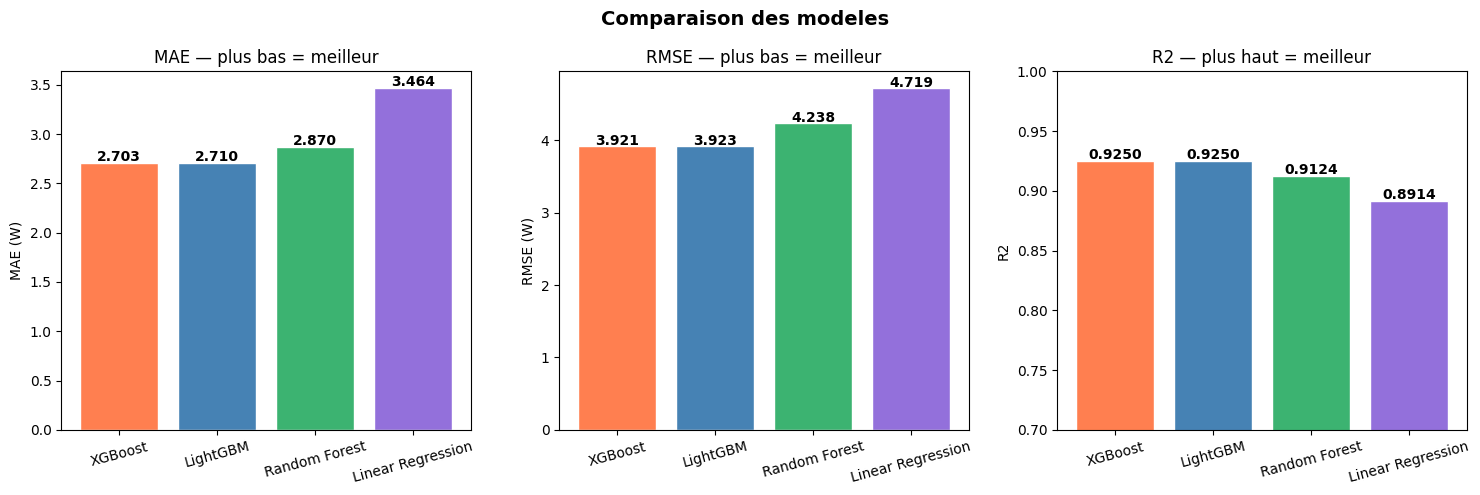

In [ ]:
# ================================================
# ETAPE 24 : VISUALISATION COMPARATIVE
# ================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparaison des modeles', fontsize=14, fontweight='bold')

modeles  = df_resultats['Modele'].tolist()
couleurs = ['coral','steelblue','mediumseagreen','mediumpurple']

bars = axes[0].bar(modeles, df_resultats['MAE'], color=couleurs, edgecolor='white')
axes[0].set_title('MAE — plus bas = meilleur')
axes[0].set_ylabel('MAE (W)')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, df_resultats['MAE']):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                  bar.get_height()+0.02,
                  f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(modeles, df_resultats['RMSE'], color=couleurs, edgecolor='white')
axes[1].set_title('RMSE — plus bas = meilleur')
axes[1].set_ylabel('RMSE (W)')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, df_resultats['RMSE']):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                  bar.get_height()+0.02,
                  f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

bars3 = axes[2].bar(modeles, df_resultats['R2'], color=couleurs, edgecolor='white')
axes[2].set_title('R2 — plus haut = meilleur')
axes[2].set_ylabel('R2')
axes[2].set_ylim(0.7, 1.0)
axes[2].tick_params(axis='x', rotation=15)
for bar, val in zip(bars3, df_resultats['R2']):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                  bar.get_height()+0.002,
                  f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

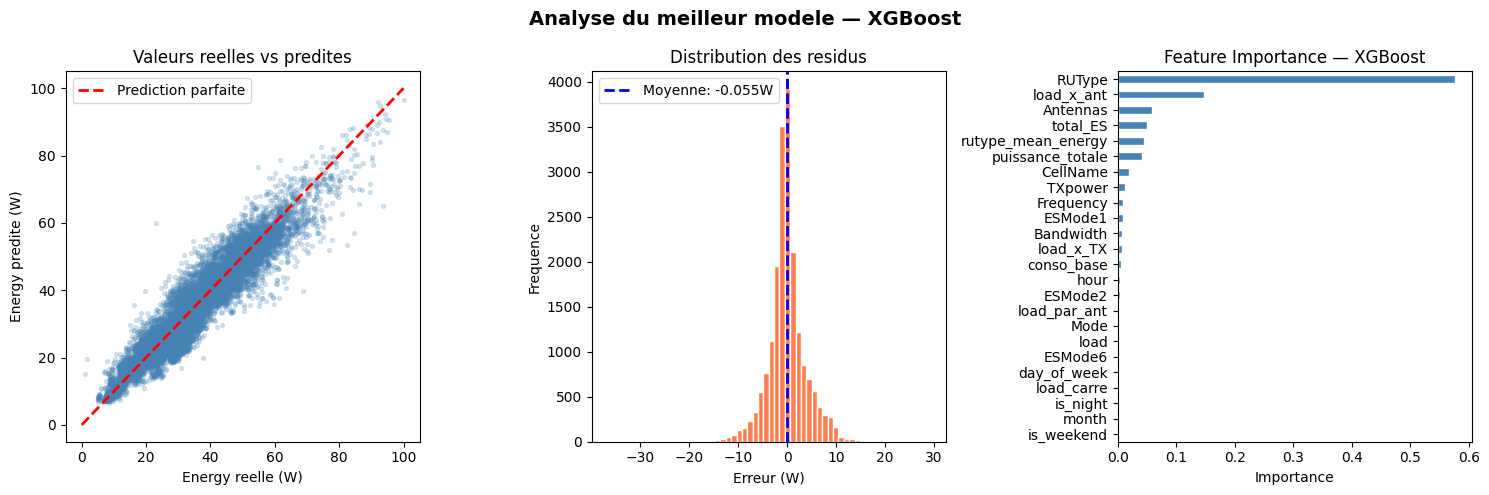

Top 5 features :
RUType                0.5763
load_x_ant            0.1471
Antennas              0.0580
total_ES              0.0491
rutype_mean_energy    0.0448
dtype: float32


In [ ]:
# ================================================
# ETAPE 25 : ANALYSE DU MEILLEUR MODELE
# ================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Analyse du meilleur modele — XGBoost', fontsize=14, fontweight='bold')

axes[0].scatter(y_val, y_pred_xgb, alpha=0.2, color='steelblue', s=8)
axes[0].plot([0,100],[0,100],'r--',lw=2,label='Prediction parfaite')
axes[0].set_title('Valeurs reelles vs predites')
axes[0].set_xlabel('Energy reelle (W)')
axes[0].set_ylabel('Energy predite (W)')
axes[0].legend()

residus = y_val - y_pred_xgb
axes[1].hist(residus, bins=60, color='coral', edgecolor='white')
axes[1].axvline(0, color='red', lw=2, linestyle='--')
axes[1].axvline(residus.mean(), color='blue', lw=2, linestyle='--',
                label=f'Moyenne: {residus.mean():.3f}W')
axes[1].set_title('Distribution des residus')
axes[1].set_xlabel('Erreur (W)')
axes[1].set_ylabel('Frequence')
axes[1].legend()

fi = pd.Series(xgb.feature_importances_,
               index=X_train.columns).sort_values(ascending=True)
fi.plot(kind='barh', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('Feature Importance — XGBoost')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print(f'Top 5 features :')
print(fi.sort_values(ascending=False).head(5).round(4))

Valeurs réelles vs prédites : les points suivent bien la ligne rouge diagonale — le modèle prédit correctement. On voit une légère dispersion pour les valeurs élevées (>60W) — c'est normal car les heures de pointe sont plus rares dans les données.Résidus : la distribution est centrée autour de 0 (-0.06W) et symétrique — le modèle ne sur-estime ni ne sous-estime systématiquement. C'est le signe d'un bon modèle.Feature Importance — résultats très importants :

RUType = 54.8% — le type d'antenne est de loin la feature la plus importante
load_x_ant = 17.5% — l'interaction charge × antennes est la 2ème plus importante
Antennas = 6% — le nombre d'antennes seul
total_ES = 5.2% — les modes économie ont un impact réel
puissance_totale = 5% — la puissance totale rayonnée

Reentrainement sur toutes les donnees...
Predictions : 27491 valeurs
Min  : 5.62 W
Max  : 95.86 W
Moy  : 29.48 W


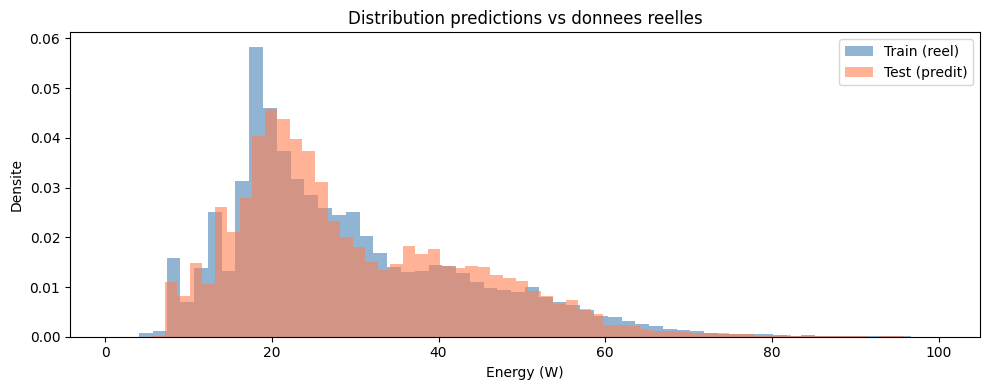

Fichier submission.csv cree !


In [ ]:
# ================================================
# ETAPE 26 : PREDICTIONS FINALES
# ================================================

print('Reentrainement sur toutes les donnees...')
modele_final = XGBRegressor(n_estimators=500, learning_rate=0.05,
                             max_depth=6, random_state=42,
                             n_jobs=-1, verbosity=0)
modele_final.fit(X, y, verbose=False)

predictions = modele_final.predict(X_test_final)

print(f'Predictions : {len(predictions)} valeurs')
print(f'Min  : {predictions.min():.2f} W')
print(f'Max  : {predictions.max():.2f} W')
print(f'Moy  : {predictions.mean():.2f} W')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y, bins=60, alpha=0.6, color='steelblue',
        label='Train (reel)', density=True)
ax.hist(predictions, bins=60, alpha=0.6, color='coral',
        label='Test (predit)', density=True)
ax.set_title('Distribution predictions vs donnees reelles')
ax.set_xlabel('Energy (W)')
ax.set_ylabel('Densite')
ax.legend()
plt.tight_layout()
plt.show()

submission = pd.DataFrame({'Energy': predictions})
submission.to_csv('submission.csv', index=False)
print('Fichier submission.csv cree !')

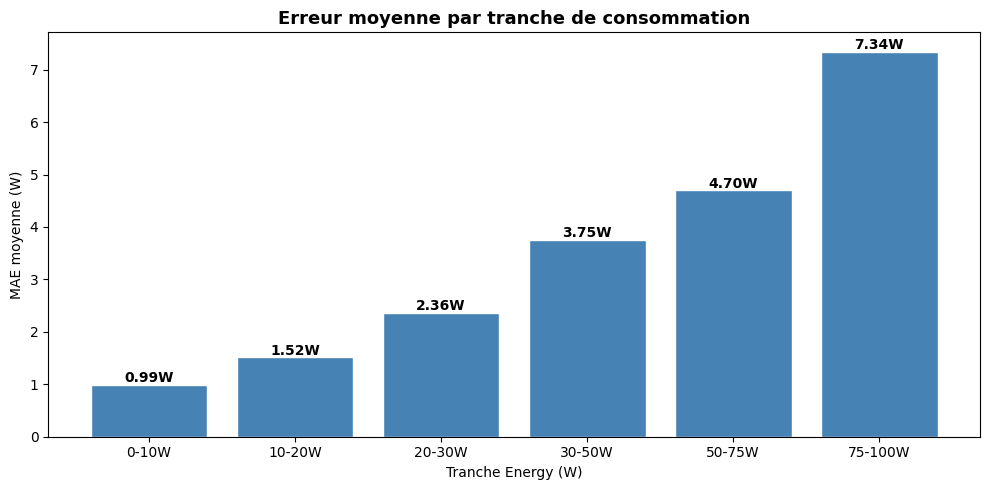

MAE par tranche :
tranche
0-10W      0.994
10-20W     1.516
20-30W     2.363
30-50W     3.752
50-75W     4.700
75-100W    7.345
Name: erreur, dtype: float64


In [ ]:
# ================================================
# ERREUR PAR TRANCHE DE CONSOMMATION
# (equivalent visuel de la matrice de confusion)
# ================================================

df_eval = pd.DataFrame({
    'reel'   : y_val,
    'predit' : y_pred_xgb,
    'erreur' : np.abs(y_val - y_pred_xgb)
})

df_eval['tranche'] = pd.cut(df_eval['reel'],
                              bins=[0,10,20,30,50,75,100],
                              labels=['0-10W','10-20W','20-30W',
                                      '30-50W','50-75W','75-100W'])

erreur_tranche = df_eval.groupby('tranche')['erreur'].mean()

plt.figure(figsize=(10, 5))
bars = plt.bar(erreur_tranche.index, erreur_tranche.values,
               color='steelblue', edgecolor='white')
plt.title('Erreur moyenne par tranche de consommation', fontsize=13, fontweight='bold')
plt.xlabel('Tranche Energy (W)')
plt.ylabel('MAE moyenne (W)')
for bar, val in zip(bars, erreur_tranche.values):
    plt.text(bar.get_x()+bar.get_width()/2,
              bar.get_height()+0.05,
              f'{val:.2f}W', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print('MAE par tranche :')
print(erreur_tranche.round(3))